# Gases Emitted by Vehicle EDA and LR project

In [16]:
# Importing all the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [17]:
# Importing Dataset

df = pd.read_csv(r'vehicle_emission_dataset.csv')

#### Columns:

- Vehicle Type: Type of vehicle (Car, Truck, Bus, Motorcycle).
- Fuel Type: Type of fuel used (Petrol, Diesel, Electric, Hybrid).
- Engine Size: Size of the vehicle's engine in liters.
- Age of Vehicle: Age of the vehicle in years.
- Mileage: Total distance traveled by the vehicle in kilometers or miles.
- Speed: Average speed of the vehicle in km/h or mph.
- Acceleration: Average acceleration of the vehicle in m/s².
- Road Type: Type of road where the vehicle is driving (Highway, City, Rural).
- Traffic Conditions: Traffic level during the measurement (Free flow, Moderate, Heavy).
- Temperature: Ambient temperature in °C or °F.
- Humidity: Relative humidity in percentage.
- Wind Speed: Wind speed in m/s or km/h.
- Air Pressure: Atmospheric pressure in hPa.
- CO2 Emissions: Carbon dioxide emissions in g/km.
- NOx Emissions: Nitrogen oxides emissions in g/km.
- PM2.5 Emissions: Particulate matter emissions in g/km.
- VOC Emissions: Volatile organic compounds emissions in g/km.
- SO2 Emissions: Sulfur dioxide emissions in g/km.
- Emission Level: Categorized emission level (Low, Medium, High).

In [18]:
# Shape of Dataset

df.shape

(10000, 19)

In [19]:
# Finding out the First 10 values from the Dataset

df.head(10)

,Vehicle Type,Fuel Type,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Road Type,Traffic Conditions,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions,Emission Level
0,Motorcycle,Electric,2.747609,22,291288,49.083255,1.887738,Highway,Moderate,13.880458,52.883905,18.938861,955.411642,179.930088,1.085520,0.011548,0.096207,0.022936,Medium
1,Bus,Electric,5.743714,3,188398,23.460311,3.544147,City,Heavy,19.136947,5.697343,14.716526,1035.763062,250.505219,1.285628,0.187112,0.073321,0.028021,Medium
2,Bus,Hybrid,4.606368,17,281451,115.508350,4.646886,Highway,Free flow,8.123428,3.953116,18.644522,976.207064,404.979103,0.258189,0.132398,0.014744,0.075334,High
3,Truck,Electric,3.913024,4,151321,18.540217,3.581004,Rural,Heavy,35.994893,0.509678,11.951859,966.919462,463.568608,1.040956,0.166325,0.093490,0.025324,High
4,Truck,Hybrid,1.611297,15,91810,109.596566,3.879303,Highway,Moderate,14.793481,52.450884,2.761138,953.229351,79.514604,1.583390,0.078043,0.020396,0.024986,Low
5,Car,Petrol,1.611172,13,72131,51.416772,3.753896,City,Moderate,11.186252,46.381560,13.508542,1033.407310,287.833438,1.733975,0.056361,0.093165,0.069062,Medium
6,Car,Petrol,1.102035,26,169449,45.343919,1.604893,City,Free flow,-7.591602,94.046019,4.029823,956.011529,337.869581,1.470222,0.042899,0.050660,0.058193,High
7,Car,Hybrid,5.304116,26,296695,27.758376,3.784652,Highway,Moderate,19.950754,34.230632,6.919372,1045.443042,57.864243,0.895289,0.110929,0.053711,0.078112,Low
8,Car,Electric,3.925798,18,90214,76.290760,3.922604,City,Moderate,20.143447,65.822740,10.192359,1006.484202,131.561709,0.589205,0.060648,0.058605,0.038697,Low
9,Bus,Electric,4.481977,13,38599,82.263362,2.667002,Highway,Heavy,19.164482,0.756341,3.147320,1019.868318,78.152711,0.839388,0.177221,0.018437,0.064761,Low


In [20]:
# Finding out the First 10 values from the Dataset

df.tail(10)

,Vehicle Type,Fuel Type,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Road Type,Traffic Conditions,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions,Emission Level
9990,Truck,Petrol,3.141993,0,127661,31.415589,3.805144,City,Free flow,1.145115,17.439959,11.014958,950.465212,342.323167,1.948951,0.031802,0.015939,0.022350,High
9991,Car,Diesel,2.490691,22,257519,36.430060,2.087277,City,Moderate,31.293980,24.622180,8.082311,976.400773,299.612580,1.155548,0.105767,0.044319,0.040723,Medium
9992,Truck,Hybrid,3.249774,8,125645,43.520362,0.331863,City,Heavy,36.363182,43.691775,2.935142,981.662139,215.763383,0.964077,0.155566,0.087382,0.024518,Medium
9993,Motorcycle,Hybrid,5.057438,5,7553,60.295651,3.467501,Highway,Heavy,11.350120,66.547758,13.440742,1018.313947,383.567033,1.762395,0.027579,0.071790,0.043921,High
9994,Bus,Petrol,1.447994,29,163903,81.895317,2.554930,City,Heavy,38.099126,15.573164,16.363147,997.665743,212.408565,0.399979,0.135182,0.056554,0.013761,Medium
9995,Motorcycle,Electric,5.259811,1,67323,60.526870,1.665292,Highway,Moderate,0.107381,28.128314,9.221882,1034.277856,380.616106,0.977784,0.162235,0.089424,0.054463,High
9996,Bus,Diesel,5.467046,5,252851,114.120190,1.174369,City,Free flow,37.641697,20.696240,8.927107,958.678711,135.691599,0.338428,0.076185,0.077451,0.099687,Low
9997,Bus,Petrol,5.722881,8,44810,11.987215,0.598791,Highway,Free flow,35.140403,86.267431,15.105582,1020.702178,315.706170,1.265111,0.082554,0.052279,0.088755,High
9998,Bus,Hybrid,2.866938,2,58719,95.832661,1.475712,Rural,Heavy,-6.692706,64.800649,10.002372,1037.489415,210.794670,0.180733,0.062148,0.077239,0.055793,Medium
9999,Car,Petrol,1.929130,15,242020,40.137971,2.292448,Rural,Free flow,16.066580,46.849574,15.712252,992.132708,422.860000,1.962348,0.045526,0.089488,0.062835,High


In [21]:
# Extracts all the Information about the Dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Vehicle Type        10000 non-null  object 
 1   Fuel Type           10000 non-null  object 
 2   Engine Size         10000 non-null  float64
 3   Age of Vehicle      10000 non-null  int64  
 4   Mileage             10000 non-null  int64  
 5   Speed               10000 non-null  float64
 6   Acceleration        10000 non-null  float64
 7   Road Type           10000 non-null  object 
 8   Traffic Conditions  10000 non-null  object 
 9   Temperature         10000 non-null  float64
 10  Humidity            10000 non-null  float64
 11  Wind Speed          10000 non-null  float64
 12  Air Pressure        10000 non-null  float64
 13  CO2 Emissions       10000 non-null  float64
 14  NOx Emissions       10000 non-null  float64
 15  PM2.5 Emissions     10000 non-null  float64
 16  VOC E

In [22]:
# Finding out the Summaries 

df.describe()

,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.369630,14.490000,148995.708000,59.448818,2.491924,14.935772,50.144758,10.027946,1000.199354,273.747254,1.043678,0.105300,0.054611,0.055105
std,1.495677,8.584339,87068.385915,34.437175,1.446130,14.432900,28.787763,5.735533,28.789590,130.789943,0.548226,0.054933,0.025971,0.026076
min,0.800061,0.000000,56.000000,0.000664,0.000084,-9.995320,0.000843,0.003425,950.013001,50.045412,0.100056,0.010005,0.010005,0.010005
25%,2.080910,7.000000,73589.750000,29.502708,1.245908,2.331247,25.731917,5.060126,975.096398,158.448360,0.565941,0.057322,0.031919,0.032710
50%,3.361149,15.000000,148914.500000,59.701114,2.482625,15.013688,49.947395,10.052823,1000.787886,274.734257,1.047428,0.105113,0.054669,0.054948
75%,4.648033,22.000000,224359.500000,88.499982,3.747481,27.423980,75.273523,15.044782,1025.092893,387.958329,1.513206,0.153704,0.076847,0.077687
max,5.998532,29.000000,299863.000000,119.974725,4.999861,39.997848,99.993970,19.997502,1049.986720,499.996419,1.999954,0.199957,0.099993,0.099980


In [23]:
# Searching for the any NULL values 

df.isnull().sum()

Vehicle Type          0
Fuel Type             0
Engine Size           0
Age of Vehicle        0
Mileage               0
Speed                 0
Acceleration          0
Road Type             0
Traffic Conditions    0
Temperature           0
Humidity              0
Wind Speed            0
Air Pressure          0
CO2 Emissions         0
NOx Emissions         0
PM2.5 Emissions       0
VOC Emissions         0
SO2 Emissions         0
Emission Level        0
dtype: int64

In [24]:
# Finding out the Duplicate values

print(df.duplicated().sum())

0


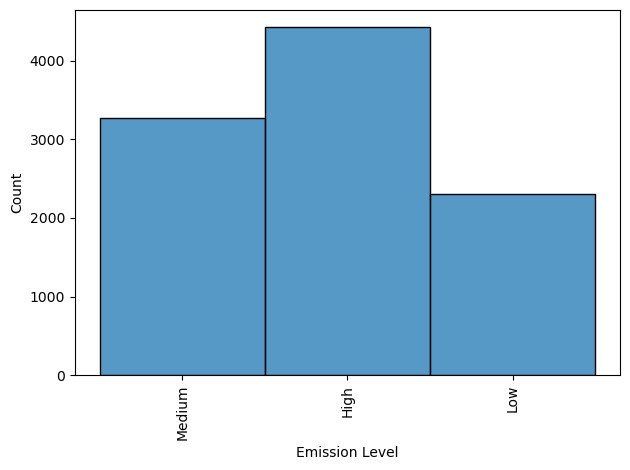

In [42]:
sns.histplot(data=df, x='Emission Level')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [43]:
df.head()

,Vehicle Type,Fuel Type,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Road Type,Traffic Conditions,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions,Emission Level
0,Motorcycle,Electric,2.747609,22,291288,49.083255,1.887738,Highway,Moderate,13.880458,52.883905,18.938861,955.411642,179.930088,1.085520,0.011548,0.096207,0.022936,Medium
1,Bus,Electric,5.743714,3,188398,23.460311,3.544147,City,Heavy,19.136947,5.697343,14.716526,1035.763062,250.505219,1.285628,0.187112,0.073321,0.028021,Medium
2,Bus,Hybrid,4.606368,17,281451,115.508350,4.646886,Highway,Free flow,8.123428,3.953116,18.644522,976.207064,404.979103,0.258189,0.132398,0.014744,0.075334,High
3,Truck,Electric,3.913024,4,151321,18.540217,3.581004,Rural,Heavy,35.994893,0.509678,11.951859,966.919462,463.568608,1.040956,0.166325,0.093490,0.025324,High
4,Truck,Hybrid,1.611297,15,91810,109.596566,3.879303,Highway,Moderate,14.793481,52.450884,2.761138,953.229351,79.514604,1.583390,0.078043,0.020396,0.024986,Low


In [44]:
df.columns

Index(['Vehicle Type', 'Fuel Type', 'Engine Size', 'Age of Vehicle', 'Mileage',
       'Speed', 'Acceleration', 'Road Type', 'Traffic Conditions',
       'Temperature', 'Humidity', 'Wind Speed', 'Air Pressure',
       'CO2 Emissions', 'NOx Emissions', 'PM2.5 Emissions', 'VOC Emissions',
       'SO2 Emissions', 'Emission Level'],
      dtype='object')

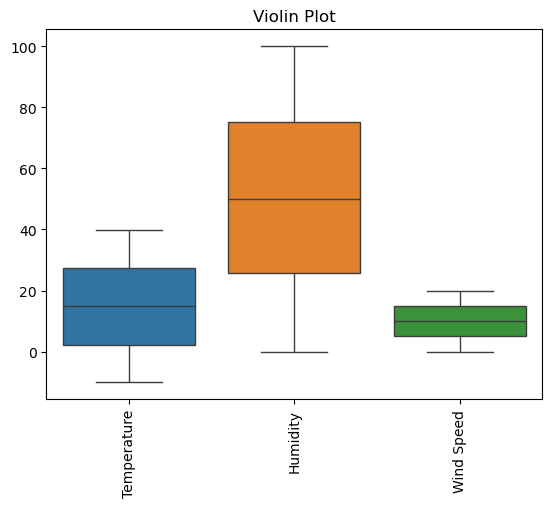

In [49]:
fuelCon = df[['Temperature', 'Humidity', 'Wind Speed']]
sns.boxplot(data=fuelCon)
plt.xticks(rotation=90)
plt.title('Violin Plot')
plt.show()

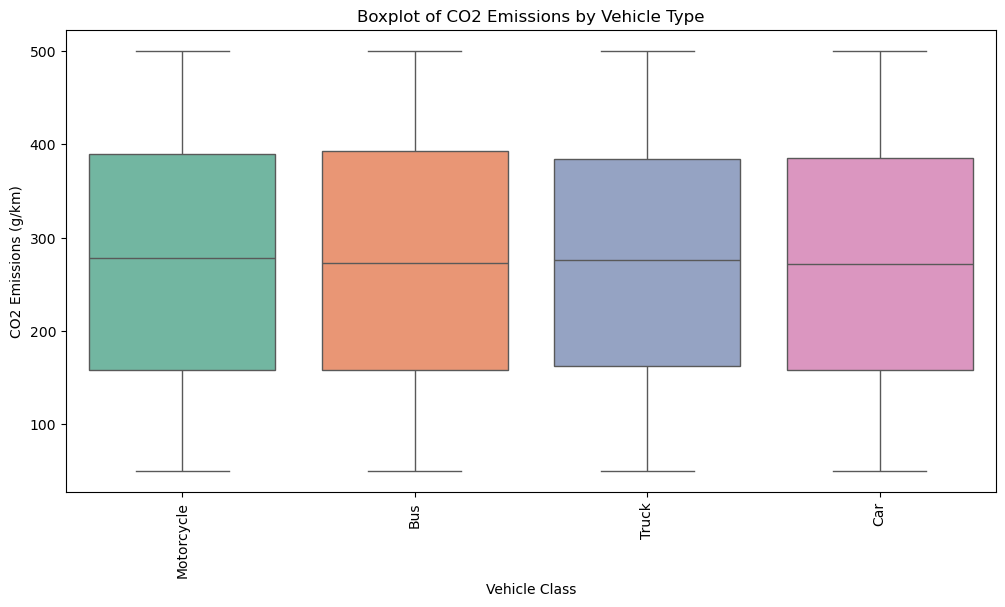

In [51]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Vehicle Type', y='CO2 Emissions', data=df, palette='Set2')
plt.title('Boxplot of CO2 Emissions by Vehicle Type')
plt.xlabel('Vehicle Class')
plt.ylabel('CO2 Emissions (g/km)')
plt.xticks(rotation=90)
plt.show()

In [52]:
num_col = df.select_dtypes("number")
corr_df  = num_col.corr()
corr_df.style.background_gradient("coolwarm")

,Engine Size,Age of Vehicle,Mileage,Speed,Acceleration,Temperature,Humidity,Wind Speed,Air Pressure,CO2 Emissions,NOx Emissions,PM2.5 Emissions,VOC Emissions,SO2 Emissions
Engine Size,1.000000,0.015602,0.005450,-0.013256,-0.000956,-0.009046,0.001027,0.003364,-0.005806,-0.007012,-0.012385,0.009119,0.020015,0.000152
Age of Vehicle,0.015602,1.000000,-0.017742,0.007851,0.007241,0.010839,0.007058,0.006290,0.000704,0.004094,0.001470,0.001223,-0.019397,-0.008718
Mileage,0.005450,-0.017742,1.000000,-0.019590,0.005336,-0.015832,0.002569,0.016899,0.003995,0.007949,-0.007269,0.010060,-0.002548,0.002737
Speed,-0.013256,0.007851,-0.019590,1.000000,0.009779,0.003933,-0.009210,-0.006854,-0.002256,0.017507,-0.010850,0.003771,-0.008564,0.019576
Acceleration,-0.000956,0.007241,0.005336,0.009779,1.000000,0.000495,-0.000758,-0.016755,0.001950,-0.018159,0.008810,-0.000608,0.009308,0.001758
Temperature,-0.009046,0.010839,-0.015832,0.003933,0.000495,1.000000,-0.007448,0.006155,0.003036,-0.004650,0.002071,0.000727,0.013532,-0.001979
Humidity,0.001027,0.007058,0.002569,-0.009210,-0.000758,-0.007448,1.000000,-0.011823,0.017778,0.015763,-0.005073,-0.011795,-0.008029,-0.000014
Wind Speed,0.003364,0.006290,0.016899,-0.006854,-0.016755,0.006155,-0.011823,1.000000,-0.015103,0.005126,0.013374,0.004581,0.017621,-0.000831
Air Pressure,-0.005806,0.000704,0.003995,-0.002256,0.001950,0.003036,0.017778,-0.015103,1.000000,-0.001180,-0.018435,0.001124,-0.001305,0.012699
CO2 Emissions,-0.007012,0.004094,0.007949,0.017507,-0.018159,-0.004650,0.015763,0.005126,-0.001180,1.000000,0.004167,0.018188,-0.005874,0.024794


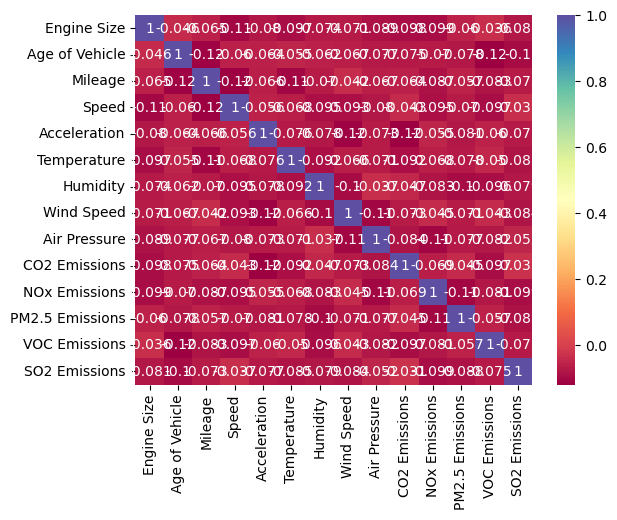

In [53]:
corr = corr_df.corr()
sns.heatmap(corr, annot=True, cmap='Spectral');

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder

In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
x = df.drop(['Emission Level'],axis=1)
y = df[['Emission Level']]

In [ ]:
x.head()

In [ ]:
# Different Split Size
train_sizes = [0.60, 0.80, 0.90]

# Different Regression Model
models = {
    "Linear"    : LinearRegression(),
    "Ridge"     : Ridge(),
    "Lasso"     : Lasso(),
    "ElasticNet": ElasticNet(),
    "XGBRegessor" : XGBRegressor(),
    "LGBMRegressor" : LGBMRegressor(),
}

# Creating empty list
results=[]

# Using Loops for training on each Split train size
for train_size in train_sizes:
    # test_size = round(1 - train_size, 2)       # if we want to put test size as test_size

    # Spliting the data
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, train_size=train_size, random_state=42
    )

    # Applying different Regression Model
    for model_name, model in models.items():
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        # Adding the Data into the Dictionary
        results.append({
            "Model Name" : model_name,
            "Train %" : f"{int(train_size*100)}%",
            "No. of Train Data" : len(x_train),
            "No. of Test Data" : len(x_test),
            "R2 Score" : round(r2_score(y_test, y_pred)*100, 4),
            "MAE" : round(mean_absolute_error(y_test, y_pred), 4),
            "MSE" : round(mean_squared_error(y_test, y_pred), 4),
            "RMSE" : round(root_mean_squared_error(y_test, y_pred), 4),
            "MAPE" : round(mean_absolute_percentage_error(y_test, y_pred), 4),
        })

df = pd.DataFrame(results)
results_df = df.sort_values(
    by='Model Name',
    ascending=True
)
print(results_df.to_string(index=False))